In [1]:
# Import libraries
import pandas as pd
import requests
import anthropic
import urllib
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

1. Complete the full Wednesday script — Azure SQL, IBGE API, merge, Claude API analysis, charts, Excel export.

In [2]:
# Connection to Azure SQL
load_dotenv()

conn = urllib.parse.quote_plus(
    f"DRIVER=ODBC Driver 17 for SQL Server;"
    f"SERVER={os.getenv('DB_SERVER')};"
    f"DATABASE={os.getenv('DB_NAME')};"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')}"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={conn}")
print("Connected to Azure SQL!")

Connected to Azure SQL!


In [3]:
# Pull revenue by state
df_revenue = pd.read_sql("""
    SELECT
		c.customer_state,
		COUNT(DISTINCT o.order_id) AS total_orders,
		ROUND(SUM(p.payment_value), 2) AS total_revenue
	FROM olist_orders_dataset o
	JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
	JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
	WHERE o.order_status = 'delivered'
	GROUP BY c.customer_state
	ORDER BY total_revenue DESC
""", engine)

df_revenue.head(5)

,customer_state,total_orders,total_revenue
0,SP,40500,5770266.19
1,RJ,12350,2055690.45
2,MG,11354,1819277.61
3,RS,5345,861802.40
4,PR,4923,781919.55


In [4]:
# Import missing library
import json

url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2021/variaveis/9324?localidades=N3[all]"

response = requests.get(url, timeout = 15)
response.raise_for_status()
data = response.json()

print("Status: ", response.status_code)
print("Rows returned: ", len(data))

if data:
    print(json.dumps(data[0], indent = 2, ensure_ascii = False))
else:
    print("No data returned for this aggregate/period/variable combination.")

Status:  200
Rows returned:  1
{
  "id": "9324",
  "variavel": "População residente estimada",
  "unidade": "Pessoas",
  "resultados": [
    {
      "classificacoes": [],
      "series": [
        {
          "localidade": {
            "id": "11",
            "nivel": {
              "id": "N3",
              "nome": "Unidade da Federação"
            },
            "nome": "Rondônia"
          },
          "serie": {
            "2021": "1815278"
          }
        },
        {
          "localidade": {
            "id": "12",
            "nivel": {
              "id": "N3",
              "nome": "Unidade da Federação"
            },
            "nome": "Acre"
          },
          "serie": {
            "2021": "906876"
          }
        },
        {
          "localidade": {
            "id": "13",
            "nivel": {
              "id": "N3",
              "nome": "Unidade da Federação"
            },
            "nome": "Amazonas"
          },
          "serie": {
        

In [5]:
# Pull population data from IBGE API
state_map = {
    "11":"RO","12":"AC","13":"AM","14":"RR","15":"PA",
    "16":"AP","17":"TO","21":"MA","22":"PI","23":"CE",
    "24":"RN","25":"PB","26":"PE","27":"AL","28":"SE",
    "29":"BA","31":"MG","32":"ES","33":"RJ","35":"SP",
    "41":"PR","42":"SC","43":"RS","50":"MS","51":"MT",
    "52":"GO","53":"DF"
}

rows = []

for code, uf in state_map.items():
    url = f"https://servicodados.ibge.gov.br/api/v1/pesquisas/indicadores/29171/resultados/{code}"
    try:
        r = requests.get(url, timeout = 15)
        r.raise_for_status()
        payload = r.json()

        res = payload[0]['res'][0]['res']
        rows.append({
            "state_code": code,
            "customer_state": uf,
            "population_2024": int(res.get("2024")) if res.get("2024") else None,
            "population_2025": int(res.get("2025")) if res.get("2025") else None,
        })
        print(f'{uf}: OK')

    except Exception as e:
        print(f"{uf}: Failed - {e}")

df_population = pd.DataFrame(rows)
print(df_population)

RO: OK
AC: OK
AM: OK
RR: OK
PA: OK
AP: OK
TO: OK
MA: OK
PI: OK
CE: OK
RN: OK
PB: OK
PE: OK
AL: OK
SE: OK
BA: OK
MG: OK
ES: OK
RJ: OK
SP: OK
PR: OK
SC: OK
RS: OK
MS: OK
MT: OK
GO: OK
DF: OK
   state_code customer_state  population_2024  population_2025
0          11             RO          1746227          1751950
1          12             AC           880631           884372
2          13             AM          4281209          4321616
3          14             RR           716793           738772
4          15             PA          8664306          8711196
5          16             AP           802837           806517
6          17             TO          1577342          1586859
7          21             MA          7010960          7018211
8          22             PI          3375646          3384547
9          23             CE          9233656          9268836
10         24             RN          3446071          3455236
11         25             PB          4145040          

In [6]:
# Checking DF Population 
df_population.head(5)

,state_code,customer_state,population_2024,population_2025
0,11,RO,1746227,1751950
1,12,AC,880631,884372
2,13,AM,4281209,4321616
3,14,RR,716793,738772
4,15,PA,8664306,8711196


In [7]:
# Parsing the API response
records = []

for item in data:
    for res in item.get("resultados", []):
        for loc in res.get("series", []):
            state_id = loc["localidade"]["id"]
            state_code = state_map.get(state_id, state_id)

            values = loc["serie"]
            latest_year = max(values.keys())
            population = int(values[latest_year])

            records.append({
                "customer_state": state_code,
                "population": population
            })

df_population = pd.DataFrame(records)
print(df_population.head())

  customer_state  population
0             RO     1815278
1             AC      906876
2             AM     4269995
3             RR      652713
4             PA     8777124


In [8]:
# Merging both sources in Pandas
df_combined = pd.merge(
    df_revenue,
    df_population,
    on = 'customer_state',
    how = 'inner'
)

# Calculate revenue per capita
df_combined["revenue_per_capita"] = (
    df_combined["total_revenue"] / df_combined["population"]
).round(4)

# Sort revenue per capita
df_combined = df_combined.sort_values("revenue_per_capita", ascending = False)

print(f"Combined: {len(df_combined)} states")
print(df_combined[["customer_state","total_revenue","population","revenue_per_capita"]])

Combined: 27 states
   customer_state  total_revenue  population  revenue_per_capita
0              SP     5770266.19    46649132              0.1237
1              RJ     2055690.45    17463349              0.1177
7              DF      346146.17     3094325              0.1119
2              MG     1819277.61    21411923              0.0850
5              SC      595208.40     7338473              0.0811
9              ES      317682.65     4108508              0.0773
3              RS      861802.40    11466630              0.0752
4              PR      781919.55    11597484              0.0674
13             MT      181441.72     3567234              0.0509
16             MS      134421.54     2839188              0.0473
8              GO      334294.22     7206589              0.0464
6              BA      591270.60    14985284              0.0395
21             TO       60007.37     1607363              0.0373
15             PB      137834.65     4059905              0.0340
17   

In [9]:
# Connecting to Claude API
load_dotenv(override = True)

key = os.getenv("ANTHROPIC_API_KEY")
print("Key loaded:", key[:10] + "..." if key else "NOT FOUND")

Key loaded: sk-ant-api...


In [10]:
# Connect to Claude API
client = anthropic.Anthropic(api_key = os.getenv("ANTHROPIC_API_KEY"))

# Prepare data summary to send to Claude
top5    = df_combined.head(5)[["customer_state","total_revenue","revenue_per_capita"]].to_string()
bottom5 = df_combined.tail(5)[["customer_state","total_revenue","revenue_per_capita"]].to_string()

prompt = f"""
You are a senior data analyst for Olist, a Brazilian e-commerce marketplace.

Top 5 states by revenue per capita:
{top5}

Bottom 5 states by revenue per capita:
{bottom5}

Provide:
1. Three key business insights from this data
2. Two actionable recommendations for the Olist team
3. Which state is the biggest growth opportunity and why
Keep your response concise and business focused.
"""

try:
    message = client.messages.create(
        model = "claude-opus-4-6",
        max_tokens = 1000,
        system = "You are a senior data analyst. Be concise and business focused.",
        messages = [{"role": "user", "content": prompt}]
    )
    ai_insights = message.content[0].text
    print("Claude API response:")
    print(ai_insights)
except Exception as e:
    print(f"Claude API error: {e}")
    ai_insights = "AI analysis unavailable"

Claude API response:
## Analysis: Revenue Per Capita by State

### Three Key Business Insights

1. **Massive disparity in market penetration:** SP's revenue per capita (R$0.124) is **19x higher** than AM's (R$0.007), indicating Olist's platform adoption is heavily concentrated in the Southeast/South regions rather than reflecting a uniform national presence.

2. **DF punches above its weight:** Despite being a small federal district, Brasília ranks #3 in revenue per capita (R$0.112), likely driven by higher average incomes and urban density—suggesting affluent, urbanized populations are Olist's sweet spot.

3. **The entire North region underperforms:** AM, RR, AP, and AC all sit in the bottom 5. This is likely a compound effect of logistics challenges (Amazon region), lower purchasing power, and limited seller/delivery infrastructure—not just low awareness.

### Two Actionable Recommendations

1. **Prioritize logistics partnerships in the North/Northeast:** Partner with regional carrie

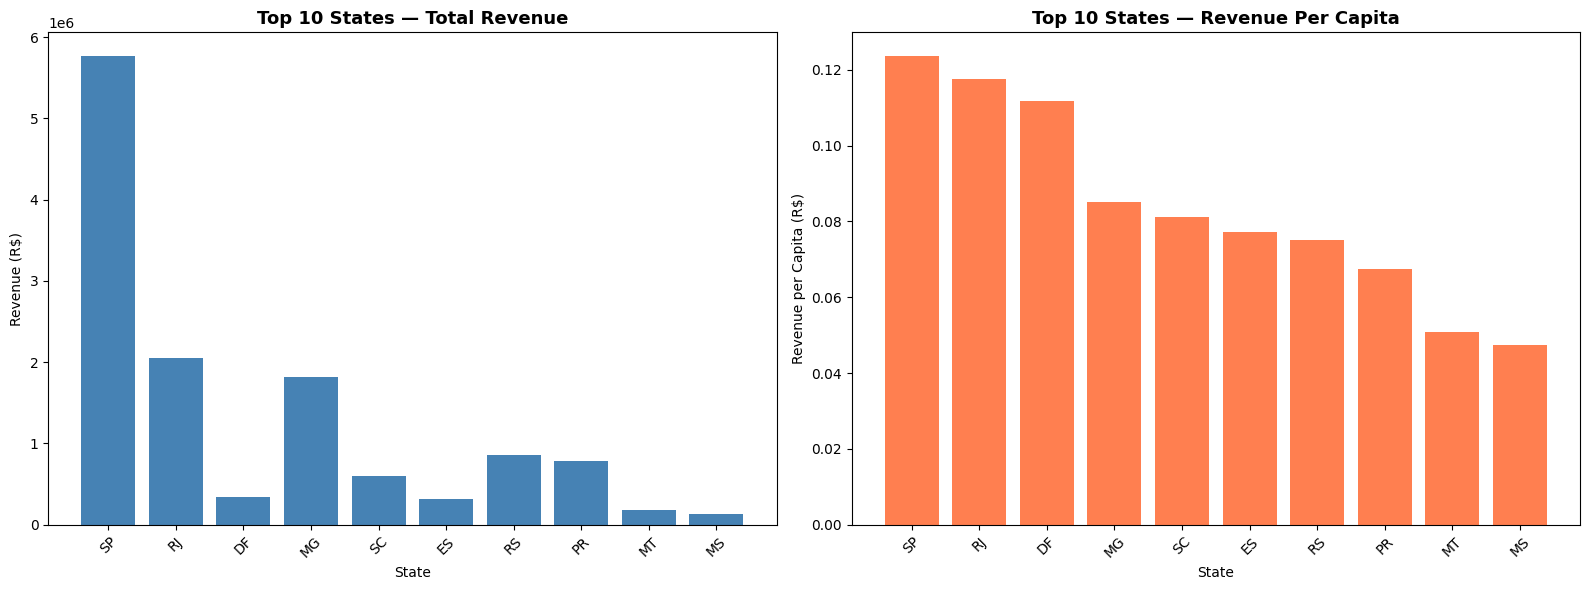

Charts saved to olist_state_analysis.png


In [11]:
# Two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top10 = df_combined.head(10)

# Chart 1 — Total revenue by state
ax1.bar(top10["customer_state"], top10["total_revenue"], color="steelblue")
ax1.set_title("Top 10 States — Total Revenue", fontweight="bold", fontsize=13)
ax1.set_xlabel("State")
ax1.set_ylabel("Revenue (R$)")
ax1.tick_params(axis="x", rotation=45)

# Chart 2 — Revenue per capita
ax2.bar(top10["customer_state"], top10["revenue_per_capita"], color="coral")
ax2.set_title("Top 10 States — Revenue Per Capita", fontweight="bold", fontsize=13)
ax2.set_xlabel("State")
ax2.set_ylabel("Revenue per Capita (R$)")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("images/olist_state_analysis.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("Charts saved to olist_state_analysis.png")

In [14]:
# Export data to an excel file
with pd.ExcelWriter("datasets/week2_olist_report.xlsx") as writer:
    df_revenue.to_excel(writer,    sheet_name = "Revenue by State",  index = False)
    df_population.to_excel(writer, sheet_name = "Population Data",   index = False)
    df_combined.to_excel(writer,   sheet_name = "Combined Analysis", index = False)
    pd.DataFrame({"Claude AI Insights": [ai_insights]}).to_excel(
        writer, sheet_name = "AI Insights", index = False
    )

print("Report saved to week2_olist_report.xlsx")
print("4 sheets: Revenue by State, Population Data, Combined Analysis, AI Insights")

Report saved to week2_olist_report.xlsx
4 sheets: Revenue by State, Population Data, Combined Analysis, AI Insights


2. Filter the combined dataframe to only states with more than 1000 orders. How many qualify?

In [16]:
# Getting states with orders above 1000
states_above_thousand = df_combined[df_combined['total_orders'] > 1000]

print(len(states_above_thousand))

12


3. Add a column that classifies each state as High Value, Medium Value, or Low Value based on revenue per capita.

In [17]:
df_combined['Value Category'] = pd.qcut(
    df_combined['revenue_per_capita'],
    q = 3,
    labels = ['Low Value', 'Medium Value', 'High Value']
)

df_combined.columns

Index(['customer_state', 'total_orders', 'total_revenue', 'population',
       'revenue_per_capita', 'Value Category'],
      dtype='str')

In [18]:
df_combined['Value Category']

0       High Value
1       High Value
7       High Value
2       High Value
5       High Value
9       High Value
3       High Value
4       High Value
13      High Value
16    Medium Value
8     Medium Value
6     Medium Value
21    Medium Value
15    Medium Value
17    Medium Value
10    Medium Value
22    Medium Value
20    Medium Value
11       Low Value
18       Low Value
19       Low Value
12       Low Value
24       Low Value
14       Low Value
25       Low Value
26       Low Value
23       Low Value
Name: Value Category, dtype: category
Categories (3, str): ['Low Value' < 'Medium Value' < 'High Value']

4. Create a scatter plot showing total revenue on X axis and revenue per capita on Y axis. Label each point with the state code.

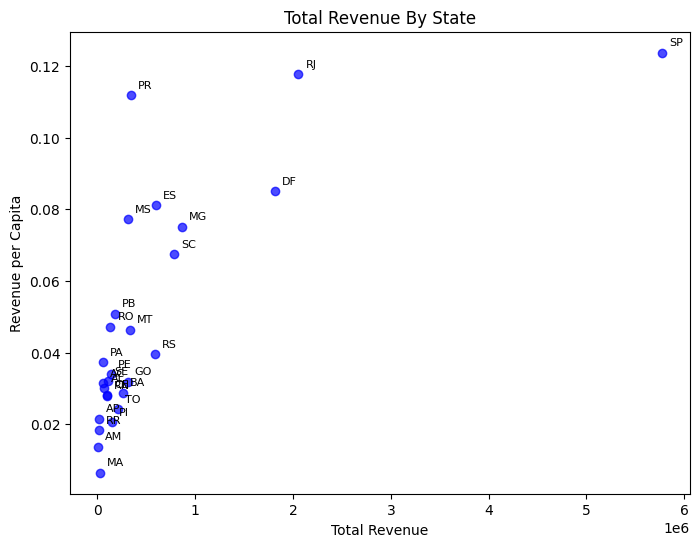

In [19]:
# Creating my scatter plot, total revenue vs revenue per capita
x = df_combined['total_revenue']
y = df_combined['revenue_per_capita']

plt.figure(figsize = (8, 6))
plt.scatter(x, y, color = 'blue', alpha = 0.7)

for i, txt in enumerate(df_combined['customer_state']):
    plt.annotate(txt, (x[i], y[i]), textcoords = "offset points", xytext = (5, 5), fontsize = 8)

plt.title('Total Revenue By State')
plt.xlabel('Total Revenue')
plt.ylabel('Revenue per Capita')
plt.show()

5. Ask Claude a different question about the data. Try asking it to predict which state will grow fastest next year and why.

In [20]:
# Prepare data summary to ask Claude
state_prompt = f"""
You are a senior data analyst for Olist, a Brazilian e-commerce marketplace.

Top 5 states by revenue per capita:
{top5}

Bottom 5 states by revenue per capita:
{bottom5}

Can you try to predict which state will grow faster next year and why?
"""

try:
    message = client.messages.create(
        model = "claude-opus-4-6",
        max_tokens = 1000,
        system = "You are a senior data analyst. Be concise and business focused.",
        messages = [{"role": "user", "content": state_prompt}]
    )
    ai_insights = message.content[0].text
    print("Claude API response:")
    print(ai_insights)
except Exception as e:
    print(f"Claude API error: {e}")
    ai_insights = "AI analysis unavailable"

Claude API response:
# Predictive Growth Analysis: Which States Will Grow Fastest?

## Prediction: **Northern/Northeastern states (MA, AM, AC, AP) will grow fastest in relative terms**

Here's my reasoning:

---

## 1. The Underpenetration Thesis

The bottom 5 states have revenue per capita **5-19x lower** than São Paulo. This isn't explained by income differences alone — it signals **low e-commerce adoption**, which represents massive headroom:

| State | Current Rev/Capita | Gap vs. SP | Growth Potential |
|-------|-------------------|------------|-----------------|
| AM | R$0.0065 | 19x below | **Very High** |
| RR | R$0.0138 | 9x below | **Very High** |
| AP | R$0.0184 | 7x below | High |
| MA | R$0.0207 | 6x below | High |
| AC | R$0.0216 | 6x below | High |

## 2. Key Growth Drivers Favoring These States

- **Internet penetration is rapidly expanding** in the North/Northeast — each new connected household is a net-new customer
- **Lack of physical retail infrastructure** in remot

6. Add a third data source — load the sellers dataset from Azure SQL. Find which states have the most sellers. Add this to your Excel report.